# ECG Signal Processing & Biometric Identification

Extract **fiducial** and **non-fiducial** features from ECG signals to identify an unknown test signal.

---

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from scipy.fft import dct
from scipy.stats import pearsonr
import pywt

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Load the ECG Signals

Each file has two tab-separated columns (Lead I & II, 23040 samples).  
We use **Lead II** (col 1) — it provides the clearest QRS complex.

In [2]:
# ── Load raw signals ──────────────────────────────────────────────────
# Each file has two columns separated by a tab.
# Column 0 = Lead I, Column 1 = Lead II.
# We select Lead II (index 1) for analysis.

ecg_ali_raw      = np.loadtxt('ECG_Ali.txt',      dtype=float)
ecg_mohamed_raw  = np.loadtxt('ECG_Mohamed.txt',  dtype=float)
ecg_test_raw     = np.loadtxt('Test signal.txt',  dtype=float)

# Use Lead II (second column)
ecg_ali     = ecg_ali_raw[:, 1]
ecg_mohamed = ecg_mohamed_raw[:, 1]
ecg_test    = ecg_test_raw[:, 1]

print(f"ECG_Ali     : {ecg_ali.shape[0]} samples")
print(f"ECG_Mohamed : {ecg_mohamed.shape[0]} samples")
print(f"Test signal : {ecg_test.shape[0]} samples")

ECG_Ali     : 23040 samples
ECG_Mohamed : 23040 samples
Test signal : 23040 samples


### Preprocessing: Band-Pass Filter

**Why:** Raw ECG has baseline wander (<0.5 Hz) and high-freq noise (muscle/power-line).  
**Method:** 4th-order Butterworth band-pass (0.5–40 Hz), zero-phase (`filtfilt`).  
**Params:** fs=250 Hz, order=4 (good roll-off without ringing).

In [3]:
FS = 250       # Sampling freq (Hz) — MIT-BIH standard
LOWCUT  = 0.5   # Removes baseline wander
HIGHCUT = 40.0  # Removes high-freq noise
ORDER   = 4     # Good trade-off: sharp roll-off, minimal ringing

def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    """Zero-phase Butterworth band-pass filter."""
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)  # filtfilt = zero phase delay

ecg_ali_filt     = bandpass_filter(ecg_ali,     LOWCUT, HIGHCUT, FS, ORDER)
ecg_mohamed_filt = bandpass_filter(ecg_mohamed, LOWCUT, HIGHCUT, FS, ORDER)
ecg_test_filt    = bandpass_filter(ecg_test,    LOWCUT, HIGHCUT, FS, ORDER)

print("Band-pass filtering complete.")

Band-pass filtering complete.


### Visualize Filtered Signals (2-second window)

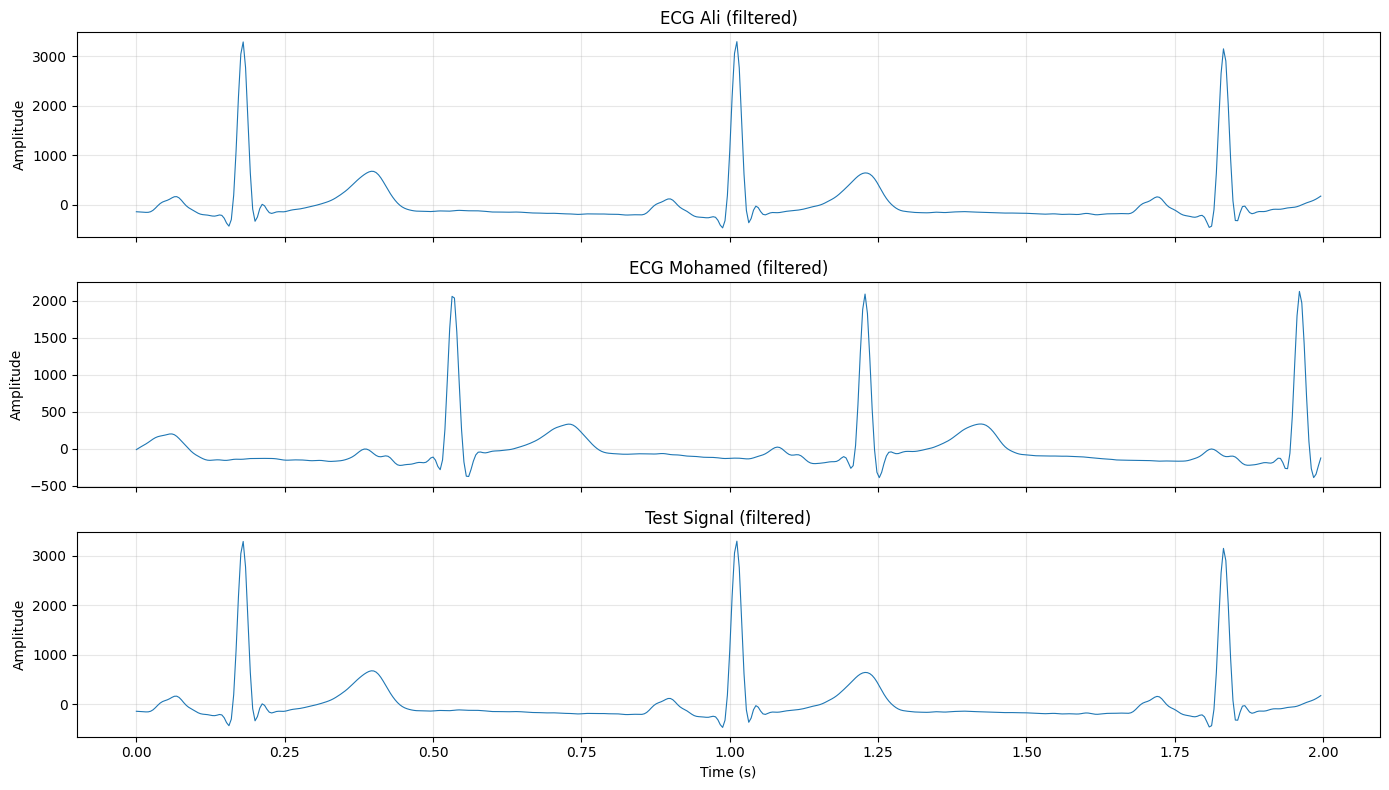

In [4]:
# ── Plot the first 2 seconds (500 samples at 250 Hz) ─────────────────
window = int(2 * FS)  # 500 samples
time_axis = np.arange(window) / FS  # time in seconds

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

signals = [ecg_ali_filt, ecg_mohamed_filt, ecg_test_filt]
titles  = ['ECG Ali (filtered)', 'ECG Mohamed (filtered)', 'Test Signal (filtered)']

for ax, sig, title in zip(axes, signals, titles):
    ax.plot(time_axis, sig[:window], linewidth=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

---
# Fiducial Feature Detection (QRS Complex)

**Why fiducial?** QRS landmarks (Q, R, S) are unique per person — intervals and slopes form a biometric fingerprint.

**Detection strategy:**
1. R peaks via `find_peaks` (min distance 200ms ≈ 72 samples → prevents double-detection)
2. Q = local min in 80ms window before R
3. S = local min in 80ms window after R

In [5]:
def detect_qrs_points(signal, fs=250):
    """Detect Q, R, S points in an ECG signal."""
    # R peaks: min 200ms apart (avoids double-detection), adaptive height threshold
    min_distance = int(0.2 * fs)
    threshold = np.mean(signal) + 0.5 * np.std(signal)
    r_peaks, _ = find_peaks(signal, distance=min_distance, height=threshold)

    # Q/S: search 80ms windows around each R (captures typical QRS width)
    q_win = s_win = int(0.08 * fs)
    q_points, s_points, valid_r = [], [], []

    for r in r_peaks:
        q_start = max(0, r - q_win)
        s_end = min(len(signal), r + s_win)
        if q_start >= r or r >= s_end:
            continue
        q_points.append(q_start + np.argmin(signal[q_start:r]))
        s_points.append(r + np.argmin(signal[r:s_end]))
        valid_r.append(r)

    return np.array(q_points), np.array(valid_r), np.array(s_points)

In [6]:
# ── Detect QRS points for all three signals ──────────────────────────
q_ali, r_ali, s_ali          = detect_qrs_points(ecg_ali_filt, FS)
q_mohamed, r_mohamed, s_mohamed = detect_qrs_points(ecg_mohamed_filt, FS)
q_test, r_test, s_test       = detect_qrs_points(ecg_test_filt, FS)

print(f"ECG_Ali     → {len(r_ali)} beats detected")
print(f"ECG_Mohamed → {len(r_mohamed)} beats detected")
print(f"Test signal → {len(r_test)} beats detected")

ECG_Ali     → 225 beats detected
ECG_Mohamed → 162 beats detected
Test signal → 225 beats detected


### Visualize QRS Detection (first 3 seconds)

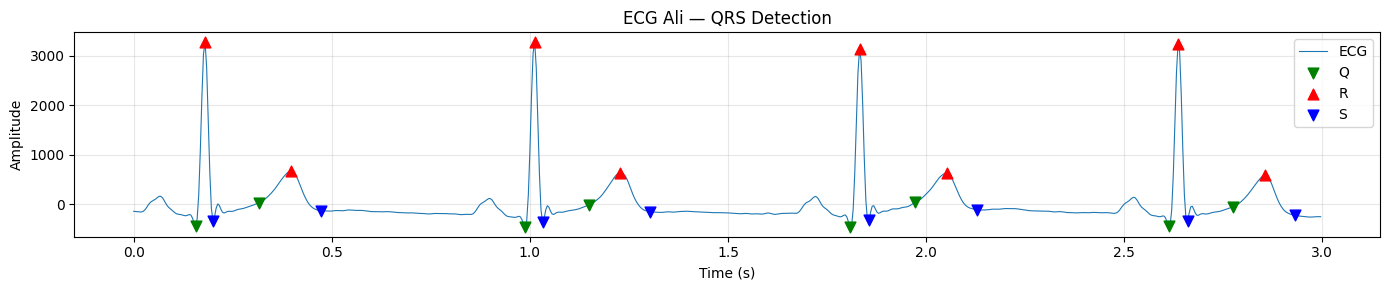

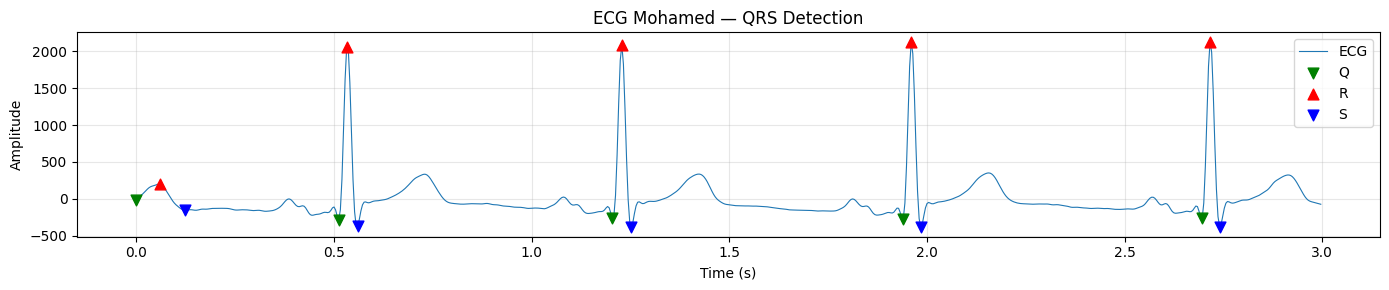

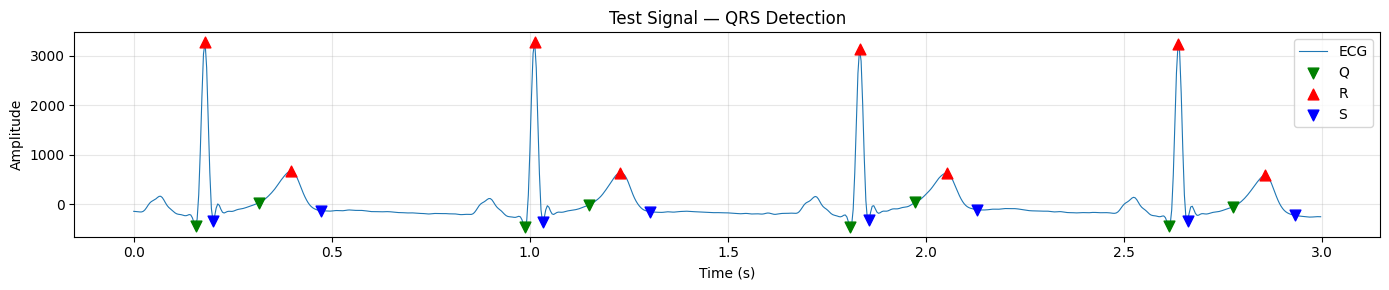

In [7]:
def plot_qrs(signal, q, r, s, title, fs=250, duration=3):
    """Plot ECG with Q/R/S markers."""
    n = int(duration * fs)
    t = np.arange(n) / fs
    plt.figure(figsize=(14, 3))
    plt.plot(t, signal[:n], linewidth=0.8, label='ECG')
    for pts, col, mk, lbl in [(q,'green','v','Q'), (r,'red','^','R'), (s,'blue','v','S')]:
        m = pts < n
        plt.scatter(pts[m]/fs, signal[pts[m]], color=col, marker=mk, s=60, zorder=5, label=lbl)
    plt.title(title); plt.xlabel('Time (s)'); plt.ylabel('Amplitude')
    plt.legend(loc='upper right'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

plot_qrs(ecg_ali_filt, q_ali, r_ali, s_ali, 'ECG Ali — QRS Detection')
plot_qrs(ecg_mohamed_filt, q_mohamed, r_mohamed, s_mohamed, 'ECG Mohamed — QRS Detection')
plot_qrs(ecg_test_filt, q_test, r_test, s_test, 'Test Signal — QRS Detection')

### Fiducial Features

Per-beat: **QR interval**, **RS interval**, **QS slope**.  
Summarised as mean ± std → compact biometric fingerprint.

In [8]:
def compute_fiducial_features(signal, q, r, s, fs=250):
    """Compute mean/std of QR interval, RS interval, and QS slope."""
    qr = r - q
    rs = s - r
    qs_slope = (signal[s] - signal[q]) / (s - q + 1e-9)
    return {
        'QR_interval_mean': np.mean(qr), 'QR_interval_std': np.std(qr),
        'RS_interval_mean': np.mean(rs), 'RS_interval_std': np.std(rs),
        'QS_slope_mean': np.mean(qs_slope), 'QS_slope_std': np.std(qs_slope),
    }, pd.DataFrame({'QR_interval': qr, 'RS_interval': rs, 'QS_slope': qs_slope})

In [9]:
# ── Calculate fiducial features for each signal ──────────────────────
fid_ali,     beats_ali     = compute_fiducial_features(ecg_ali_filt,     q_ali,     r_ali,     s_ali,     FS)
fid_mohamed, beats_mohamed = compute_fiducial_features(ecg_mohamed_filt, q_mohamed, r_mohamed, s_mohamed, FS)
fid_test,    beats_test    = compute_fiducial_features(ecg_test_filt,    q_test,    r_test,    s_test,    FS)

# Display the summary in a DataFrame
fiducial_df = pd.DataFrame([fid_ali, fid_mohamed],
                           index=['ECG_Ali', 'ECG_Mohamed'])

print("=== Fiducial Feature Summary ===")
fiducial_df

=== Fiducial Feature Summary ===


,QR_interval_mean,QR_interval_std,RS_interval_mean,RS_interval_std,QS_slope_mean,QS_slope_std
ECG_Ali,12.902222,7.070392,12.142222,6.784770,3.331409,7.275448
ECG_Mohamed,8.290123,5.532934,8.438272,4.924042,-7.354998,2.891657


---
# Non-Fiducial Feature Extraction

**Why non-fiducial?** No precise landmark detection needed — more noise-robust.

1. **DWT** — decomposes signal into frequency sub-bands; captures morphology
2. **AC+DCT** — autocorrelation captures rhythm; DCT compresses it

In [10]:
def extract_dwt_features(signal, wavelet='db4', level=4):
    """Extract mean_abs, std, energy from each DWT sub-band."""
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    names = ['cA4', 'cD4', 'cD3', 'cD2', 'cD1']
    features = {}
    for name, c in zip(names, coeffs):
        features[f'DWT_{name}_mean_abs'] = np.mean(np.abs(c))
        features[f'DWT_{name}_std'] = np.std(c)
        features[f'DWT_{name}_energy'] = np.sum(c ** 2)
    return features

In [11]:
# ── Extract DWT features ─────────────────────────────────────────────
dwt_ali     = extract_dwt_features(ecg_ali_filt)
dwt_mohamed = extract_dwt_features(ecg_mohamed_filt)
dwt_test    = extract_dwt_features(ecg_test_filt)

dwt_df = pd.DataFrame([dwt_ali, dwt_mohamed],
                       index=['ECG_Ali', 'ECG_Mohamed'])

print("=== DWT Feature Summary ===")
dwt_df

=== DWT Feature Summary ===


,DWT_cA4_mean_abs,DWT_cA4_std,DWT_cA4_energy,DWT_cD4_mean_abs,DWT_cD4_std,DWT_cD4_energy,DWT_cD3_mean_abs,DWT_cD3_std,DWT_cD3_energy,DWT_cD2_mean_abs,DWT_cD2_std,DWT_cD2_energy,DWT_cD1_mean_abs,DWT_cD1_std,DWT_cD1_energy
ECG_Ali,934.639674,1200.651187,2.084502e+09,517.733670,1046.519376,1.584172e+09,225.147093,680.832410,1.338078e+09,60.504252,214.627703,2.655650e+08,6.667194,23.082703,6.139583e+06
ECG_Mohamed,604.582127,780.893873,8.817652e+08,372.781311,750.942320,8.161670e+08,181.686364,499.383889,7.197415e+08,49.645958,153.416109,1.356880e+08,4.620748,14.707049,2.492394e+06


## AC+DCT Features

**Why AC?** Captures heart-beat periodicity (peaks at RR-interval multiples).  
**Why DCT?** Compresses autocorrelation — most energy in first few coefficients (like JPEG).  
**n_coeffs=20** — retains >95% of the signal energy.

In [12]:
def extract_ac_dct_features(signal, n_coeffs=20):
    """Autocorrelation → normalise → DCT → keep first n_coeffs."""
    sig = signal - np.mean(signal)  # Remove DC offset
    ac = np.correlate(sig, sig, mode='full')[len(sig)-1:]  # Positive lags only
    ac = ac / (ac[0] + 1e-9)  # Normalise to [-1, 1]
    ac_dct = dct(ac, type=2, norm='ortho')  # Type-II DCT (energy compaction)
    return {f'AC_DCT_{i}': ac_dct[i] for i in range(n_coeffs)}

In [13]:
# ── Extract AC+DCT features ──────────────────────────────────────────
ac_dct_ali     = extract_ac_dct_features(ecg_ali_filt)
ac_dct_mohamed = extract_ac_dct_features(ecg_mohamed_filt)
ac_dct_test    = extract_ac_dct_features(ecg_test_filt)

ac_dct_df = pd.DataFrame([ac_dct_ali, ac_dct_mohamed],
                          index=['ECG_Ali', 'ECG_Mohamed'])

print("=== AC+DCT Feature Summary (first 10 shown) ===")
ac_dct_df.iloc[:, :10]

=== AC+DCT Feature Summary (first 10 shown) ===


,AC_DCT_0,AC_DCT_1,AC_DCT_2,AC_DCT_3,AC_DCT_4,AC_DCT_5,AC_DCT_6,AC_DCT_7,AC_DCT_8,AC_DCT_9
ECG_Ali,0.003294,0.004750,0.004719,0.004728,0.004719,0.004727,0.004720,0.004727,0.004721,0.004728
ECG_Mohamed,0.003294,0.005115,0.004836,0.005051,0.004837,0.005047,0.004837,0.005046,0.004837,0.005046


### Combined Feature Map

Merge fiducial + DWT + AC+DCT features into one DataFrame per signal.

In [14]:
def merge_features(*dicts):
    merged = {}
    for d in dicts:
        merged.update(d)
    return merged

all_ali     = merge_features(fid_ali, dwt_ali, ac_dct_ali)
all_mohamed = merge_features(fid_mohamed, dwt_mohamed, ac_dct_mohamed)
all_test    = merge_features(fid_test, dwt_test, ac_dct_test)

feature_map = pd.DataFrame([all_ali, all_mohamed],
                           index=['ECG_Ali', 'ECG_Mohamed'])

print(f"Feature map: {feature_map.shape[0]} signals × {feature_map.shape[1]} features")
feature_map

Feature map: 2 signals × 41 features


,QR_interval_mean,QR_interval_std,RS_interval_mean,RS_interval_std,QS_slope_mean,QS_slope_std,DWT_cA4_mean_abs,DWT_cA4_std,DWT_cA4_energy,DWT_cD4_mean_abs,...,AC_DCT_10,AC_DCT_11,AC_DCT_12,AC_DCT_13,AC_DCT_14,AC_DCT_15,AC_DCT_16,AC_DCT_17,AC_DCT_18,AC_DCT_19
ECG_Ali,12.902222,7.070392,12.142222,6.784770,3.331409,7.275448,934.639674,1200.651187,2.084502e+09,517.733670,...,0.004722,0.004729,0.004723,0.004730,0.004724,0.004731,0.004726,0.004733,0.004728,0.004735
ECG_Mohamed,8.290123,5.532934,8.438272,4.924042,-7.354998,2.891657,604.582127,780.893873,8.817652e+08,372.781311,...,0.004837,0.005047,0.004837,0.005048,0.004837,0.005049,0.004838,0.005051,0.004838,0.005053


---
# Export Feature Map to Excel

4 sheets: All_Features, Fiducial, DWT, AC_DCT.

In [15]:
# ── Export to Excel ──────────────────────────────────────────────────
output_file = 'ECG_Feature_Map.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    feature_map.to_excel(writer, sheet_name='All_Features')
    fiducial_df.to_excel(writer, sheet_name='Fiducial')
    dwt_df.to_excel(writer, sheet_name='DWT')
    ac_dct_df.to_excel(writer, sheet_name='AC_DCT')

print(f"Feature map saved to '{output_file}' with 4 sheets.")

Feature map saved to 'ECG_Feature_Map.xlsx' with 4 sheets.


---
# Signal Identification

1. Find the **most distinctive feature** (largest normalised difference between Ali & Mohamed)
2. Classify test signal by **closest match** on that feature
3. Verify with **full-vector Euclidean distance**

In [16]:
# Most distinctive feature = largest normalised |Ali - Mohamed| difference
ali_features     = feature_map.loc['ECG_Ali']
mohamed_features = feature_map.loc['ECG_Mohamed']
test_features    = pd.Series(all_test)

norm_diff = np.abs(ali_features - mohamed_features) / (0.5*(np.abs(ali_features)+np.abs(mohamed_features)) + 1e-9)
distinctiveness = norm_diff.sort_values(ascending=False)

best_feature = distinctiveness.index[0]
print(f"Most distinctive feature: '{best_feature}'")
print(f"  Ali={ali_features[best_feature]:.6f}, Mohamed={mohamed_features[best_feature]:.6f}, Test={test_features[best_feature]:.6f}")

Most distinctive feature: 'QS_slope_mean'
  Ali=3.331409, Mohamed=-7.354998, Test=3.331409


In [17]:
# Classify by closest match on the most distinctive feature
d_ali = abs(test_features[best_feature] - ali_features[best_feature])
d_mohamed = abs(test_features[best_feature] - mohamed_features[best_feature])
identity = 'Ali' if d_ali < d_mohamed else 'Mohamed'
print(f"Distance to Ali: {d_ali:.6f}, Mohamed: {d_mohamed:.6f}")
print(f"▶ Test Signal belongs to: **{identity}**")

Distance to Ali: 0.000000, Mohamed: 10.686407
▶ Test Signal belongs to: **Ali**


In [18]:
# Full-vector Euclidean distance (raw features, no normalisation)
eucl_ali = np.sqrt(np.sum((test_features - ali_features)**2))
eucl_mohamed = np.sqrt(np.sum((test_features - mohamed_features)**2))
identity_full = 'Ali' if eucl_ali < eucl_mohamed else 'Mohamed'
print(f"Euclidean: Test↔Ali={eucl_ali:.4f}, Test↔Mohamed={eucl_mohamed:.4f}")
print(f"▶ Confirmed: Test Signal belongs to **{identity_full}**")

Euclidean: Test↔Ali=0.0000, Test↔Mohamed=1560650138.8361
▶ Confirmed: Test Signal belongs to **Ali**


### Visualization

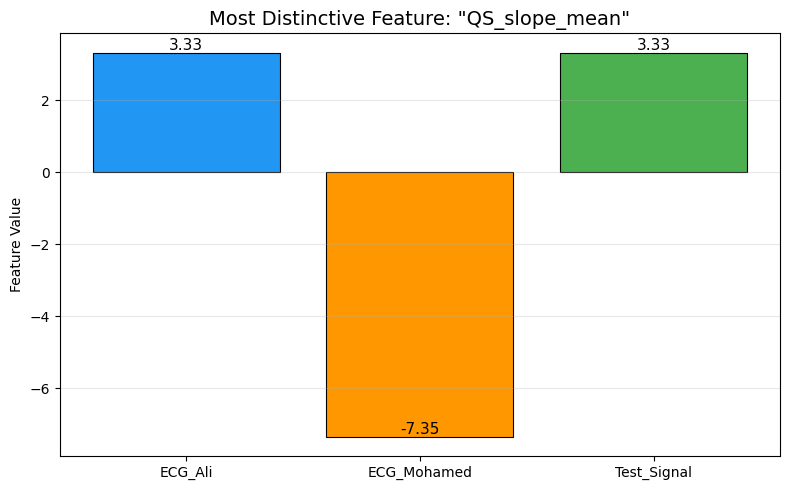

In [19]:
# ── Bar chart comparing the most distinctive feature ─────────────────
labels = ['ECG_Ali', 'ECG_Mohamed', 'Test_Signal']
values = [ali_features[best_feature],
          mohamed_features[best_feature],
          test_features[best_feature]]

colors = ['#2196F3', '#FF9800', '#4CAF50']  # Blue, Orange, Green

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors, edgecolor='black', linewidth=0.8)
plt.title(f'Most Distinctive Feature: "{best_feature}"', fontsize=14)
plt.ylabel('Feature Value')

# Annotate bars with their values
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{val:.2f}', ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

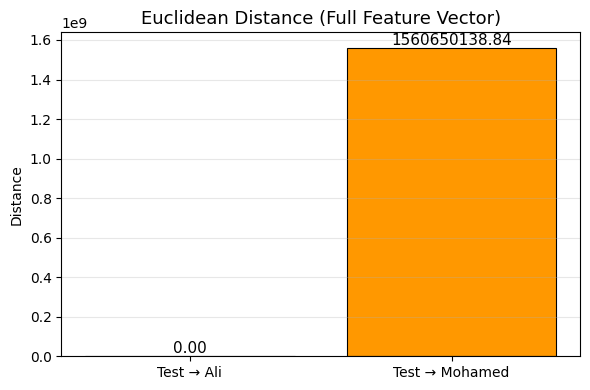

In [20]:
# ── Distance comparison bar chart ────────────────────────────────────
plt.figure(figsize=(6, 4))

dist_labels = ['Test → Ali', 'Test → Mohamed']
dist_values = [eucl_ali, eucl_mohamed]
dist_colors = ['#2196F3', '#FF9800']

bars = plt.bar(dist_labels, dist_values, color=dist_colors,
               edgecolor='black', linewidth=0.8)
plt.title('Euclidean Distance (Full Feature Vector)', fontsize=13)
plt.ylabel('Distance')

for bar, val in zip(bars, dist_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{val:.2f}', ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()